# ARRL International DX Contest SSB 2026 — Propagation Analysis

**Contest**: ARRL International DX Contest — SSB  
**Dates**: 2026-03-07 00:00 — 2026-03-08 23:59 UTC (48 hours)  
**Bands**: 160m through 10m (no WARC)  
**Mode**: SSB  
**Exchange**: W/VE send power, DX send entity  

**Analysis window**: 2026-03-06 00:00 — 2026-03-09 23:59 UTC (24h before + 24h after)  

**Data sources**:  
- **PSKR** (primary) — digital mode observations as propagation proxy (SSB not directly captured)  
- **RBN** (secondary) — minimal CW skimmer activity during an SSB weekend  
- **Solar indices** — SFI, SSN, Kp, Ap from GFZ Potsdam  
- **DSCOVR** — solar wind Bz, speed, density from L1  

**Storm hook**: A geomagnetic storm developed during the contest. Kp rose from
quiet (1.0) on Saturday morning to active (4.67) by Sunday afternoon. SFI
started at 143 and declined to 135. Quantifying the propagation impact across
bands is the centerpiece of this analysis.

This analysis is produced by the [IONIS-AI](https://github.com/IONIS-AI) and
[QSO-Graph](https://github.com/qso-graph) projects — 14.3B rows of propagation data,
71 MCP tools, and a trained model applied to contest propagation.

---

**Dataset**: `arrl-dx-ssb-2026.sqlite`  
**Download**: [SourceForge](https://sourceforge.net/projects/ionis-ai/files/contests/)

## Setup

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Imports (must come first)                                 ║
# ╚══════════════════════════════════════════════════════════════╝

import sqlite3
from pathlib import Path
from datetime import datetime, timezone, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from ionis_jupyter import (
    grid_to_latlon,
    grid_distance,
    grid_bearing,
    solar_elevation,
    classify_path,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

# ╔══════════════════════════════════════════════════════════════╗
# ║  CONTEST PARAMETERS — ARRL DX SSB 2026                     ║
# ╚══════════════════════════════════════════════════════════════╝

CONTEST_NAME = "ARRL International DX Contest — SSB"
CONTEST_MODE = "SSB"
DATASET_NAME = "arrl-dx-ssb-2026.sqlite"

# Contest window (UTC)
CONTEST_START = datetime(2026, 3, 7, 0, 0, tzinfo=timezone.utc)
CONTEST_END = datetime(2026, 3, 8, 23, 59, tzinfo=timezone.utc)

# Primary data source: "pskr" for SSB contests (voice not captured by skimmers)
PRIMARY_SOURCE = "pskr"

# Contest bands (exclude WARC for most contests)
CONTEST_BANDS = [102, 103, 105, 107, 109, 111]

# ╔══════════════════════════════════════════════════════════════╗
# ║  Everything below this line is automatic                    ║
# ╚══════════════════════════════════════════════════════════════╝

# Derived constants
BAND_NAMES = {
    102: "160m", 103: "80m", 104: "60m", 105: "40m", 106: "30m",
    107: "20m", 108: "17m", 109: "15m", 110: "12m", 111: "10m",
}
CONTEST_BAND_NAMES = {k: BAND_NAMES[k] for k in CONTEST_BANDS}
ANALYSIS_START = CONTEST_START - timedelta(hours=24)
ANALYSIS_END = CONTEST_END + timedelta(hours=24)

print(f"Contest:  {CONTEST_NAME}")
print(f"Mode:     {CONTEST_MODE}")
print(f"Window:   {CONTEST_START.strftime('%Y-%m-%d %H:%M')} — {CONTEST_END.strftime('%Y-%m-%d %H:%M')} UTC")
print(f"Primary:  {PRIMARY_SOURCE.upper()}")
print(f"Bands:    {', '.join(BAND_NAMES[b] for b in CONTEST_BANDS)}")

Contest:  ARRL International DX Contest — SSB
Mode:     SSB
Window:   2026-03-07 00:00 — 2026-03-08 23:59 UTC
Primary:  PSKR
Bands:    160m, 80m, 40m, 20m, 15m, 10m


## Load Contest Dataset

The contest dataset is a standalone SQLite file with four tables:
- `rbn_signatures` — CW skimmer observations (primary for CW contests)
- `pskr_signatures` — digital mode observations (primary for SSB/digital contests)
- `solar_timeline` — solar/geomagnetic conditions over the analysis window
- `contest_info` — contest metadata

In [2]:
# Find the dataset
# Priority: local data/ directory, then IONIS_DATA_DIR, then SourceForge contests/
import os

search_paths = [
    Path("../data") / DATASET_NAME,                                    # Repo data dir
    Path(os.environ.get("IONIS_DATA_DIR", "")) / ".." / "contests" / DATASET_NAME,
    Path.home() / ".ionis-mcp" / "data" / "contests" / DATASET_NAME,  # Default location
]

db_path = None
for p in search_paths:
    if p.exists():
        db_path = p
        break

if db_path is None:
    print(f"Dataset not found: {DATASET_NAME}")
    print(f"Download from: https://sourceforge.net/projects/ionis-ai/files/contests/")
    print(f"Place in one of: {[str(p) for p in search_paths]}")
else:
    print(f"Dataset: {db_path}")
    print(f"Size: {db_path.stat().st_size / 1024 / 1024:.1f} MB")

Dataset: ../data/arrl-dx-ssb-2026.sqlite
Size: 173.8 MB


In [3]:
# Load all tables
conn = sqlite3.connect(str(db_path))

# Contest metadata
contest_info = pd.read_sql_query("SELECT * FROM contest_info", conn)
display(contest_info)

# RBN signatures
rbn = pd.read_sql_query("SELECT * FROM rbn_signatures", conn)
print(f"\nRBN signatures: {len(rbn):,}")

# PSKR signatures
pskr = pd.read_sql_query("SELECT * FROM pskr_signatures", conn)
print(f"PSKR signatures: {len(pskr):,}")

# Solar timeline
solar = pd.read_sql_query("SELECT * FROM solar_timeline", conn)
solar["date"] = pd.to_datetime(solar["date"])
print(f"Solar timeline rows: {len(solar):,}")

conn.close()

# Set primary/secondary based on contest mode
primary = rbn if PRIMARY_SOURCE == "rbn" else pskr
secondary = pskr if PRIMARY_SOURCE == "rbn" else rbn
primary_label = "RBN (CW skimmers)" if PRIMARY_SOURCE == "rbn" else "PSKR (digital modes)"
secondary_label = "PSKR (digital proxy)" if PRIMARY_SOURCE == "rbn" else "RBN (CW skimmers)"
print(f"\nPrimary source: {primary_label} ({len(primary):,} signatures)")

,name,start_utc,end_utc,analysis_start,analysis_end,mode,bands,sfi_avg,kp_min,kp_max,pskr_sig_count,rbn_sig_count
0,ARRL International DX Contest — SSB,2026-03-07T00:00,2026-03-08T23:59,2026-03-06,2026-03-09T23:59:59,SSB,"160m,80m,60m,40m,30m,20m,17m,15m,12m,10m",134.949997,1.667,4.667,1830861,129848



RBN signatures: 129,848


PSKR signatures: 1,830,861
Solar timeline rows: 24

Primary source: PSKR (digital modes) (1,830,861 signatures)


---

## Section 1 — Contest Overview

The ARRL International DX Contest SSB weekend is one of the largest operating
events on HF. Stations outside the US/Canada work W/VE stations for DXCC entity
multipliers across 160m through 10m (no WARC bands).

For propagation analysis, SSB contests present a unique challenge:
- **SSB voice is not captured** by PSKR or RBN — no direct contest observations
- **PSKR digital modes** (FT8, WSPR) serve as a **propagation proxy** — same bands
  open, same ionospheric conditions, different modality
- **RBN CW skimmers** capture minimal activity during SSB weekends
- The analysis measures **what bands were open**, not contest scores

**The storm hook**: This contest weekend saw a developing geomagnetic storm.
Kp rose from 1.0 on Saturday morning to 4.67 by Sunday afternoon. SFI declined
from 143 to 135. The key question: how did the storm impact propagation across
bands, and can we see it in the PSKR data?

In [4]:
# Summary statistics
print("=" * 60)
print(f"{CONTEST_NAME} — Dataset Summary")
print("=" * 60)

for label, df in [(primary_label, primary), (secondary_label, secondary)]:
    print(f"\n--- {label} ---")
    print(f"  Total signatures: {len(df):,}")
    print(f"  Total spot count: {df['spot_count'].sum():,.0f}")
    print(f"  Unique TX grids:  {df['tx_grid_4'].nunique():,}")
    print(f"  Unique RX grids:  {df['rx_grid_4'].nunique():,}")
    print(f"  Unique grid pairs: {len(df.groupby(['tx_grid_4', 'rx_grid_4'])):,}")
    print(f"  Bands active: ", end="")
    for b in sorted(df["band"].unique()):
        name = BAND_NAMES.get(b, str(b))
        count = len(df[df["band"] == b])
        print(f"{name}({count:,}) ", end="")
    print()
    print(f"  Distance range: {df['avg_distance'].min():.0f} — {df['avg_distance'].max():.0f} km")
    print(f"  SNR range: {df['median_snr'].min():.1f} — {df['median_snr'].max():.1f} dB")

ARRL International DX Contest — SSB — Dataset Summary

--- PSKR (digital modes) ---
  Total signatures: 1,830,861
  Total spot count: 7,915,098
  Unique TX grids:  1,904
  Unique RX grids:  1,347


  Unique grid pairs: 321,960
  Bands active: 160m(17,496) 80m(79,585) 60m(16,436) 40m(323,562) 30m(164,626) 20m(399,505) 17m(166,346) 15m(264,366) 12m(116,988) 10m(281,951) 
  Distance range: 0 — 20015 km
  SNR range: -37.0 — 63.0 dB

--- RBN (CW skimmers) ---
  Total signatures: 129,848
  Total spot count: 506,815
  Unique TX grids:  1,420
  Unique RX grids:  157
  Unique grid pairs: 37,381
  Bands active: 160m(1,492) 80m(11,560) 60m(267) 40m(30,848) 30m(12,344) 20m(40,844) 17m(6,787) 15m(16,785) 12m(2,476) 10m(6,445) 
  Distance range: 0 — 19904 km
  SNR range: -1.0 — 67.0 dB


---

## Section 2 — Solar Conditions Timeline

Solar conditions during the contest window, extended 24 hours before and after.
Key indices:
- **SFI** (Solar Flux Index) — F-layer ionization, higher = better high-band propagation
- **SSN** (Sunspot Number) — solar activity indicator
- **Kp** — geomagnetic disturbance (0-9 scale, >4 = storm)
- **Ap** — daily geomagnetic activity
- **Bz** — interplanetary magnetic field z-component (negative = storm coupling)

In [5]:
# Solar conditions summary
print("Solar Conditions Summary")
print("-" * 40)
for col in ["sfi", "ssn", "kp", "ap"]:
    if col in solar.columns:
        vals = solar[col].dropna()
        if len(vals) > 0:
            print(f"  {col.upper():>4}: {vals.min():.1f} — {vals.max():.1f}  (mean: {vals.mean():.1f})")

# Check for DSCOVR data
if "bz_avg" in solar.columns:
    bz = solar["bz_avg"].dropna()
    if len(bz) > 0:
        print(f"    Bz: {bz.min():.1f} — {bz.max():.1f} nT (avg)")
        neg_pct = (bz < 0).sum() / len(bz) * 100
        print(f"    Bz negative: {neg_pct:.0f}% of measurements")
if "bz_min" in solar.columns:
    bz_min = solar["bz_min"].dropna()
    if len(bz_min) > 0:
        print(f"    Bz min: {bz_min.min():.1f} nT (deepest southward excursion)")

Solar Conditions Summary
----------------------------------------
   SFI: 134.5 — 142.8  (mean: 137.6)
   SSN: 79.0 — 88.0  (mean: 83.0)
    KP: 1.0 — 4.7  (mean: 2.8)
    AP: 4.0 — 39.0  (mean: 15.6)
    Bz: -6.6 — 3.1 nT (avg)
    Bz negative: 75% of measurements
    Bz min: -9.2 nT (deepest southward excursion)


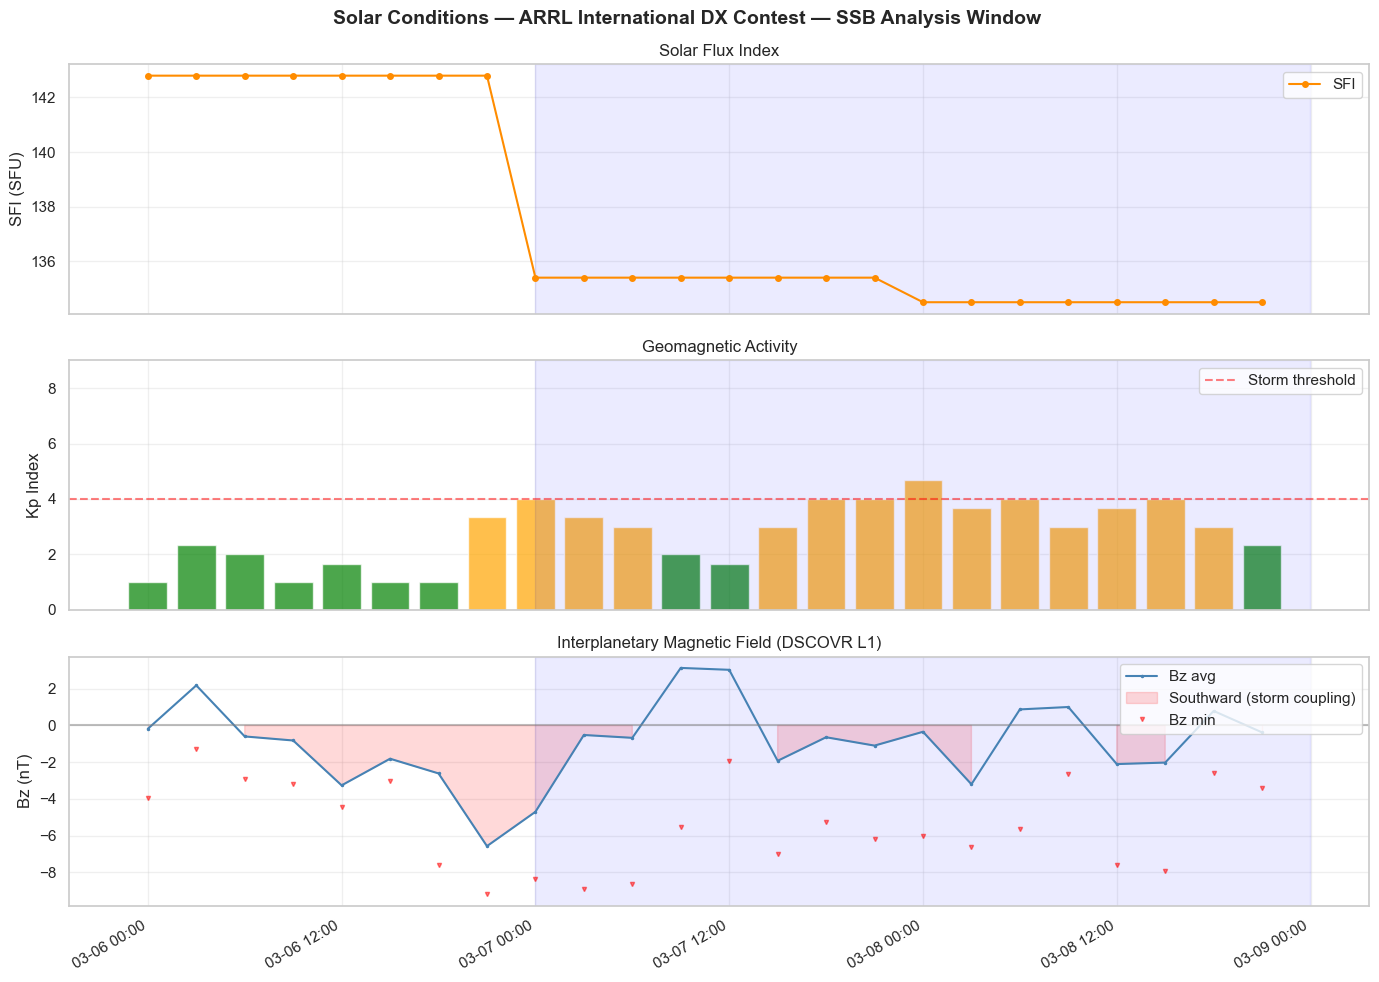

In [6]:
# Solar timeline plots
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Create datetime index for x-axis (date + hour)
solar_dt = solar.copy()
solar_dt["datetime"] = solar_dt["date"] + pd.to_timedelta(solar_dt["hour"], unit="h")

# SFI
ax = axes[0]
if "sfi" in solar_dt.columns:
    ax.plot(solar_dt["datetime"], solar_dt["sfi"], "o-", color="darkorange", markersize=4, label="SFI")
    ax.set_ylabel("SFI (SFU)")
    ax.legend(loc="upper right")
    ax.set_title("Solar Flux Index")

# Kp
ax = axes[1]
if "kp" in solar_dt.columns:
    colors_kp = ["green" if k < 3 else "orange" if k < 5 else "red" for k in solar_dt["kp"]]
    ax.bar(solar_dt["datetime"], solar_dt["kp"], color=colors_kp, width=0.1, alpha=0.7)
    ax.axhline(4, color="red", linestyle="--", alpha=0.5, label="Storm threshold")
    ax.set_ylabel("Kp Index")
    ax.set_ylim(0, 9)
    ax.legend(loc="upper right")
    ax.set_title("Geomagnetic Activity")

# Bz (if available)
ax = axes[2]
if "bz_avg" in solar_dt.columns and solar_dt["bz_avg"].notna().any():
    ax.plot(solar_dt["datetime"], solar_dt["bz_avg"], ".-", color="steelblue", markersize=3, label="Bz avg")
    ax.axhline(0, color="gray", linestyle="-", alpha=0.5)
    ax.fill_between(solar_dt["datetime"], solar_dt["bz_avg"], 0,
                    where=(solar_dt["bz_avg"] < 0), color="red", alpha=0.15, label="Southward (storm coupling)")
    if "bz_min" in solar_dt.columns:
        ax.plot(solar_dt["datetime"], solar_dt["bz_min"], "v", color="red", markersize=3, alpha=0.5, label="Bz min")
    ax.set_ylabel("Bz (nT)")
    ax.legend(loc="upper right")
    ax.set_title("Interplanetary Magnetic Field (DSCOVR L1)")
else:
    ax.text(0.5, 0.5, "DSCOVR Bz data not available", transform=ax.transAxes, ha="center")
    ax.set_title("Interplanetary Magnetic Field")

# Contest window shading
for ax in axes:
    ax.axvspan(CONTEST_START, CONTEST_END, alpha=0.08, color="blue", label="Contest window")
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.autofmt_xdate(rotation=30)
fig.suptitle(f"Solar Conditions — {CONTEST_NAME} Analysis Window", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Section 3 — Band Activity Heatmap

Hour (UTC) x Band matrix showing spot density. This reveals:
- Which bands were open at which times
- Peak activity periods
- The contest "light switch" effect — activity erupts at 00:00 UTC Saturday
  and drops off sharply at 23:59 UTC Sunday

In [7]:
def plot_activity_heatmap(df, title, ax=None):
    """Plot hour x band activity heatmap."""
    # Filter to contest bands
    contest_df = df[df["band"].isin(CONTEST_BANDS)]

    # Pivot: hour (rows) x band (columns), sum spot_count
    pivot = contest_df.groupby(["hour", "band"])["spot_count"].sum().unstack(fill_value=0)

    # Rename columns to band names
    pivot.columns = [BAND_NAMES.get(b, str(b)) for b in pivot.columns]

    # Reorder columns by frequency (160m → 10m)
    band_order = [BAND_NAMES[b] for b in CONTEST_BANDS if BAND_NAMES[b] in pivot.columns]
    pivot = pivot[band_order]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlOrRd",
        annot=True,
        fmt=",.0f",
        cbar_kws={"label": "Total Spot Count"},
        linewidths=0.5,
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Band")
    ax.set_ylabel("Hour (UTC)")
    return ax

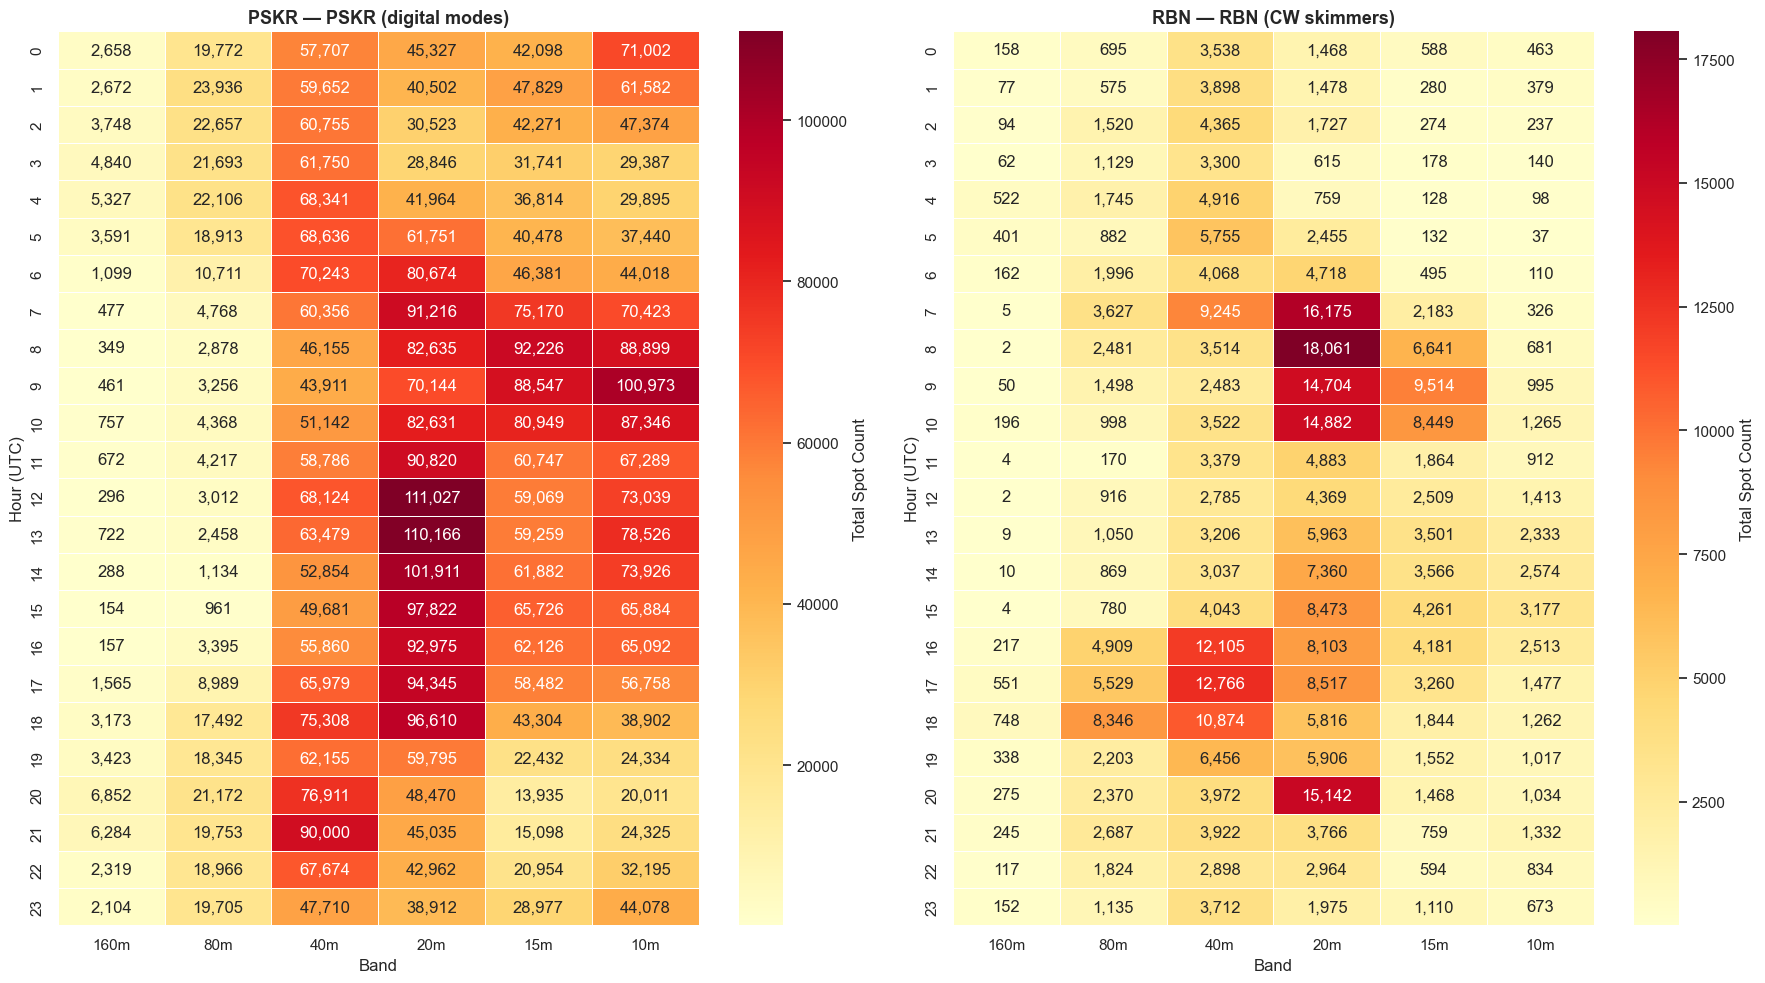

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

plot_activity_heatmap(primary, f"{PRIMARY_SOURCE.upper()} — {primary_label}", ax=axes[0])
plot_activity_heatmap(secondary, f"{('pskr' if PRIMARY_SOURCE == 'rbn' else 'rbn').upper()} — {secondary_label}", ax=axes[1])

plt.tight_layout()
plt.show()

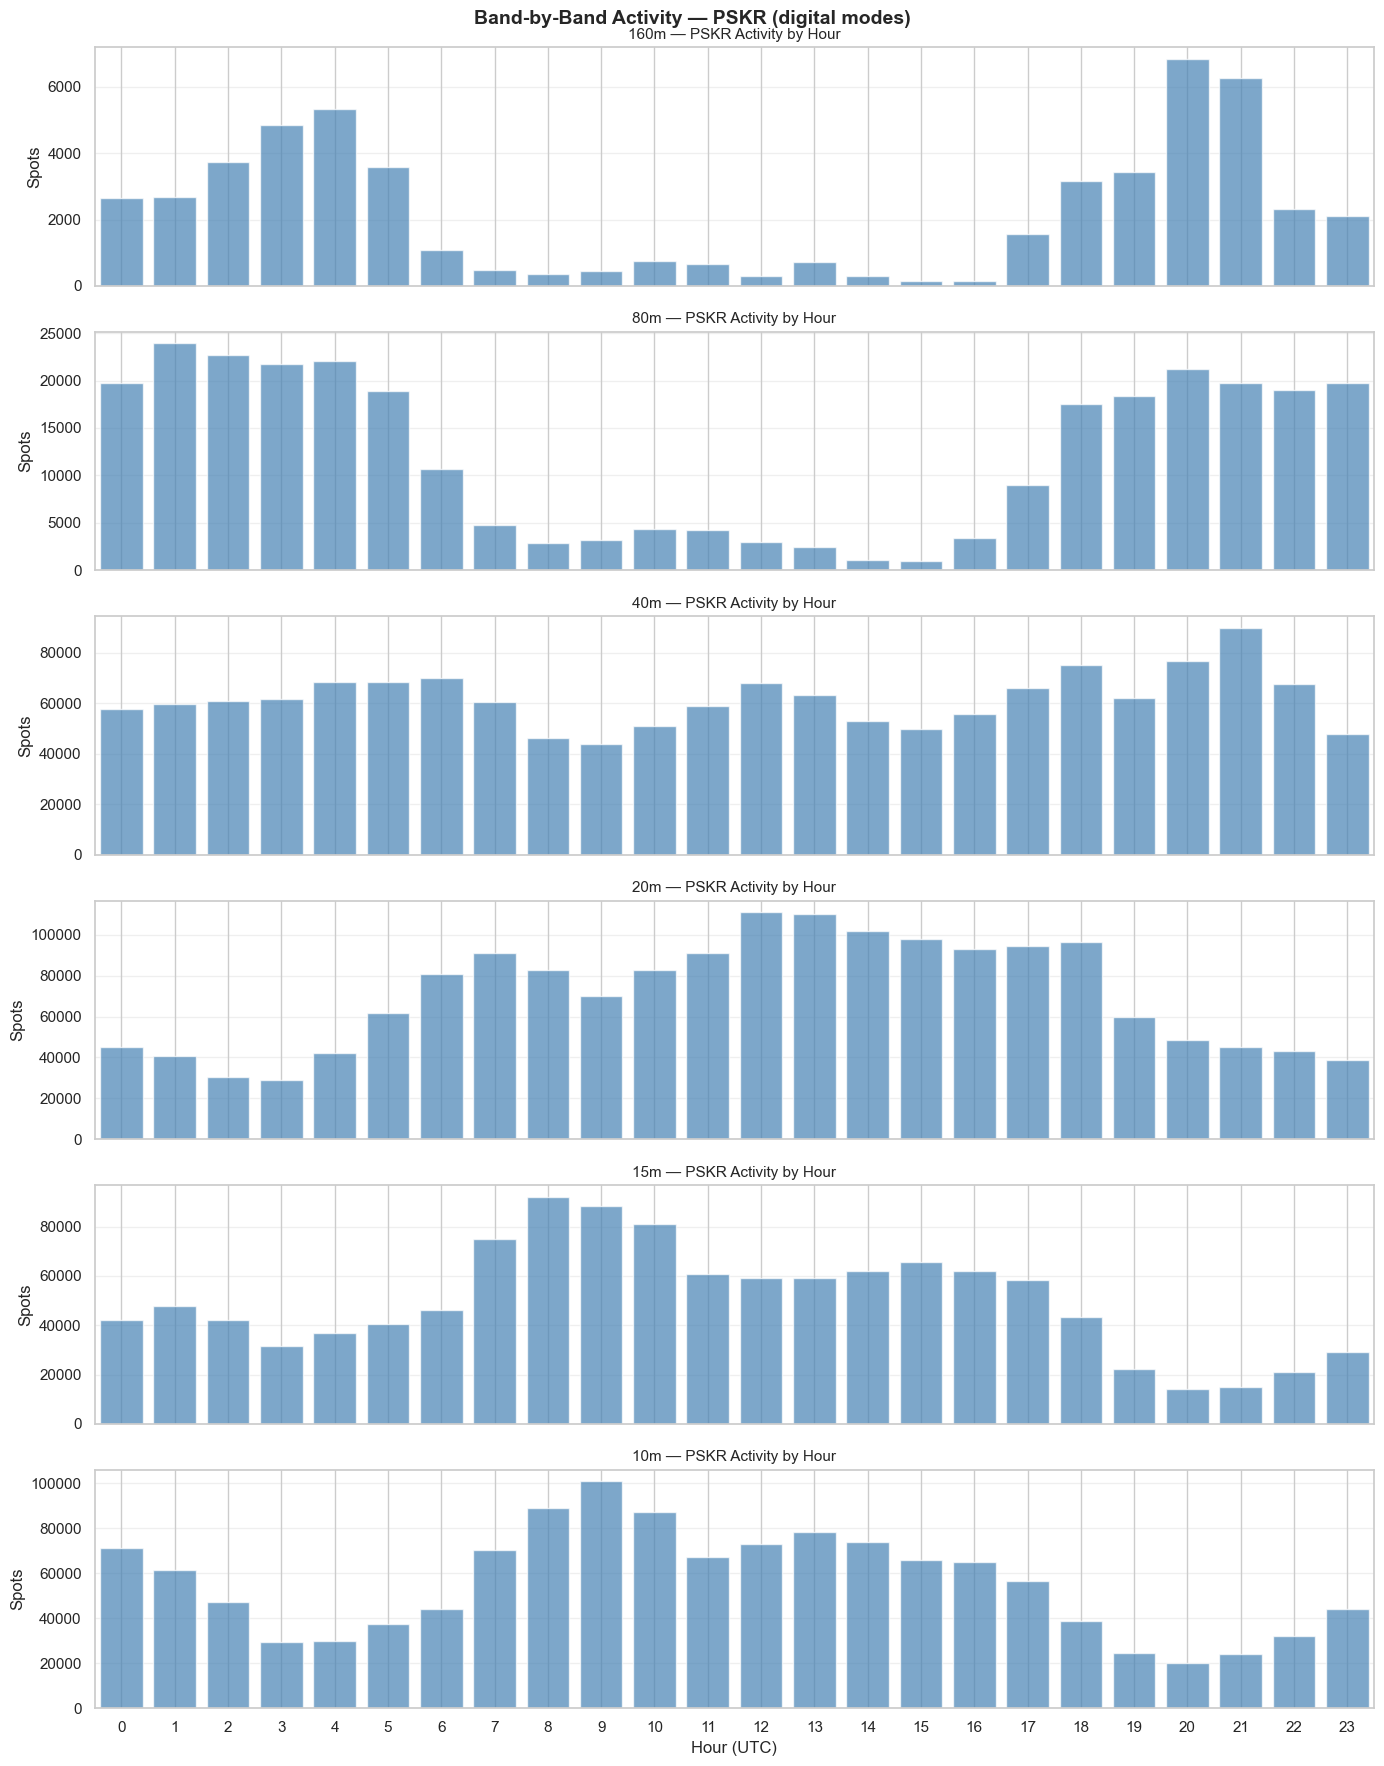

In [9]:
# Band-by-band activity timeline (primary source)
fig, axes = plt.subplots(len(CONTEST_BANDS), 1, figsize=(14, 3 * len(CONTEST_BANDS)), sharex=True)

for i, band_id in enumerate(CONTEST_BANDS):
    ax = axes[i]
    band_df = primary[primary["band"] == band_id]
    hour_activity = band_df.groupby("hour")["spot_count"].sum()

    ax.bar(hour_activity.index, hour_activity.values, color="steelblue", alpha=0.7)
    ax.set_ylabel("Spots")
    ax.set_title(f"{BAND_NAMES[band_id]} — {PRIMARY_SOURCE.upper()} Activity by Hour", fontsize=11)
    ax.set_xlim(-0.5, 23.5)
    ax.grid(True, alpha=0.3, axis="y")

axes[-1].set_xlabel("Hour (UTC)")
axes[-1].set_xticks(range(0, 24))
fig.suptitle(f"Band-by-Band Activity — {primary_label}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Section 4 — Geographic Reach

Per-band analysis of geographic coverage:
- Distance distribution histograms
- Continental breakdown (NA-EU, NA-AS, NA-SA, etc.)
- Top grid pairs by spot density

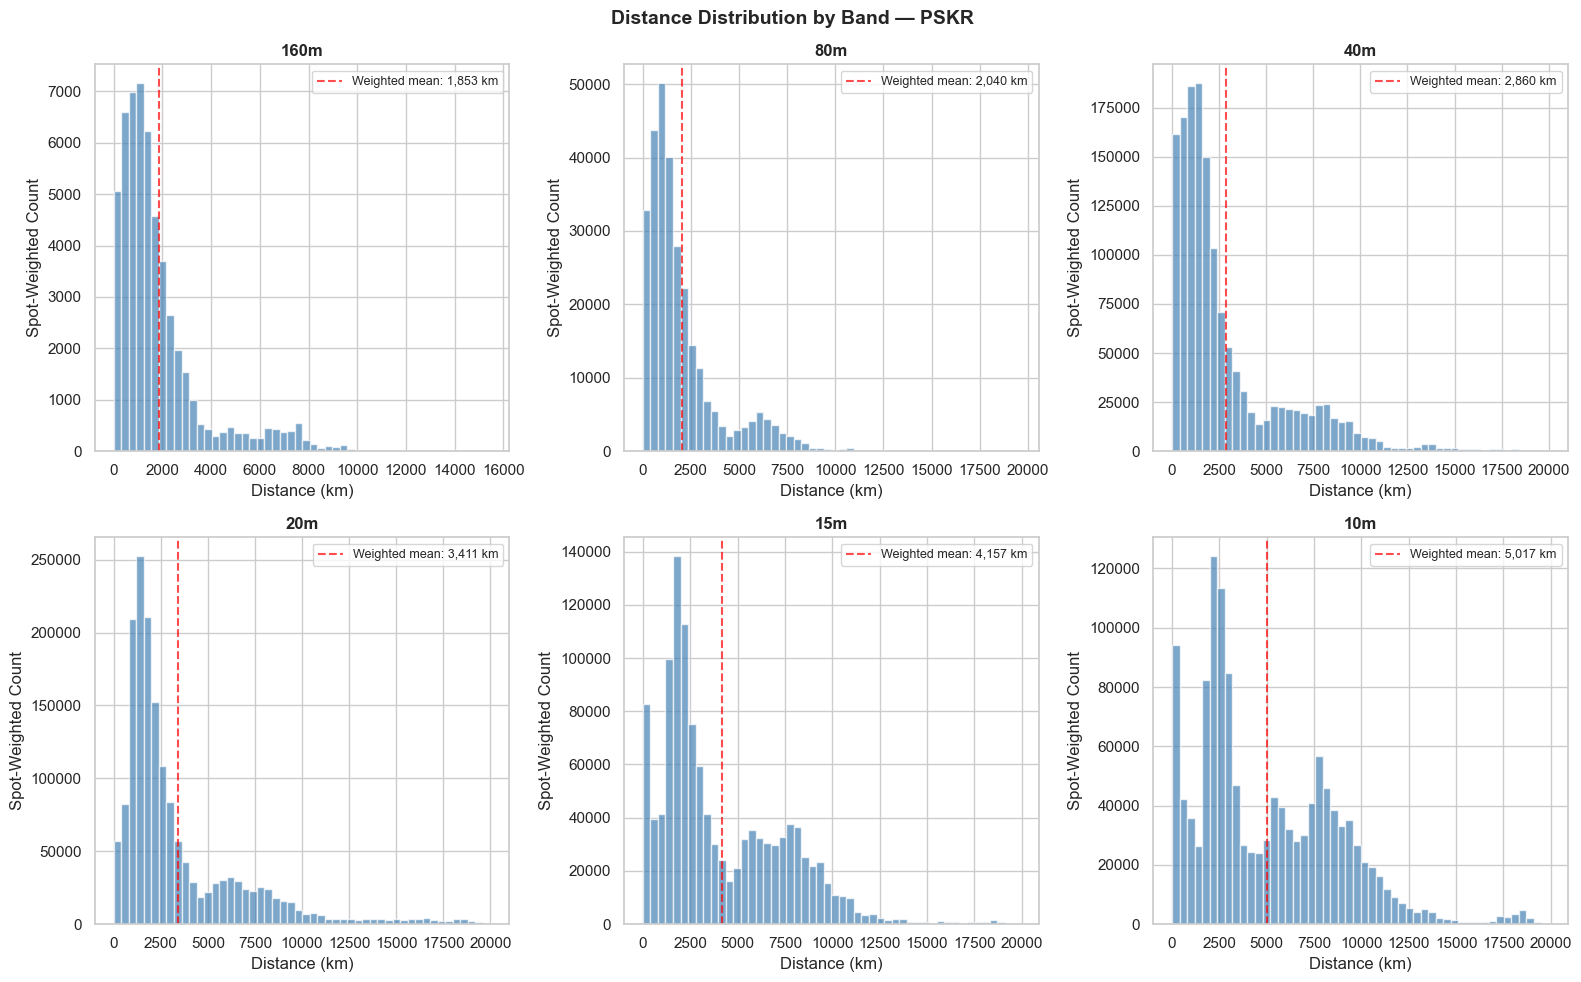

In [10]:
# Distance distribution per band
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, band_id in enumerate(CONTEST_BANDS):
    ax = axes[i // 3][i % 3]
    band_df = primary[primary["band"] == band_id]

    if len(band_df) > 0:
        ax.hist(band_df["avg_distance"], bins=50, color="steelblue", alpha=0.7,
                weights=band_df["spot_count"])
        median_dist = np.average(band_df["avg_distance"], weights=band_df["spot_count"])
        ax.axvline(median_dist, color="red", linestyle="--", alpha=0.7,
                   label=f"Weighted mean: {median_dist:,.0f} km")
        ax.legend(fontsize=9)

    ax.set_title(f"{BAND_NAMES[band_id]}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Spot-Weighted Count")

fig.suptitle(f"Distance Distribution by Band — {PRIMARY_SOURCE.upper()}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
# Continental breakdown using grid prefixes
def grid_to_continent(grid):
    """Rough continent classification from Maidenhead grid field."""
    if not grid or len(grid) < 2:
        return "Unknown"
    field = grid[:2].upper()
    lon_field = ord(field[0]) - ord('A')  # 0-17
    lat_field = ord(field[1]) - ord('A')  # 0-17

    if lat_field >= 10 and 7 <= lon_field <= 13:
        return "EU"
    if lat_field >= 7 and 9 <= lon_field <= 13:
        return "EU"
    if lat_field >= 5 and 3 <= lon_field <= 7:
        return "NA"
    if lat_field >= 2 and 4 <= lon_field <= 7:
        return "SA"
    if lat_field >= 5 and 13 <= lon_field <= 17:
        return "AS"
    if lat_field <= 5 and 13 <= lon_field <= 16:
        return "OC"
    if lat_field <= 6 and 9 <= lon_field <= 13:
        return "AF"
    return "Other"

# Add continent classification to primary source
primary_geo = primary.copy()
primary_geo["tx_continent"] = primary_geo["tx_grid_4"].apply(grid_to_continent)
primary_geo["rx_continent"] = primary_geo["rx_grid_4"].apply(grid_to_continent)
primary_geo["path"] = primary_geo["tx_continent"] + "-" + primary_geo["rx_continent"]

# Top intercontinental paths
path_stats = (
    primary_geo.groupby("path")
    .agg(signatures=("spot_count", "count"), total_spots=("spot_count", "sum"))
    .sort_values("total_spots", ascending=False)
    .head(15)
)

print(f"Top Intercontinental Paths ({PRIMARY_SOURCE.upper()})")
print("=" * 45)
for path, row in path_stats.iterrows():
    print(f"  {path:>10}: {row['signatures']:>8,} sigs, {row['total_spots']:>10,} spots")

Top Intercontinental Paths (PSKR)
       EU-EU:  855,900 sigs,  3,087,480 spots
       AS-AS:  218,785 sigs,  1,669,343 spots
       NA-NA:  192,611 sigs,    855,122 spots
       EU-NA:  150,519 sigs,    630,686 spots
       AS-EU:   89,434 sigs,    313,114 spots
       EU-AS:   80,435 sigs,    288,187 spots
       NA-EU:   76,019 sigs,    260,547 spots
    NA-Other:   39,928 sigs,    196,805 spots
    AS-Other:   25,935 sigs,    187,099 spots
       AS-NA:   34,944 sigs,    163,918 spots
    Other-NA:   17,396 sigs,     75,673 spots
    EU-Other:   12,398 sigs,     41,350 spots
       NA-AS:   10,897 sigs,     41,081 spots
  Other-Other:    5,074 sigs,     30,041 spots
    Other-AS:    4,858 sigs,     23,774 spots


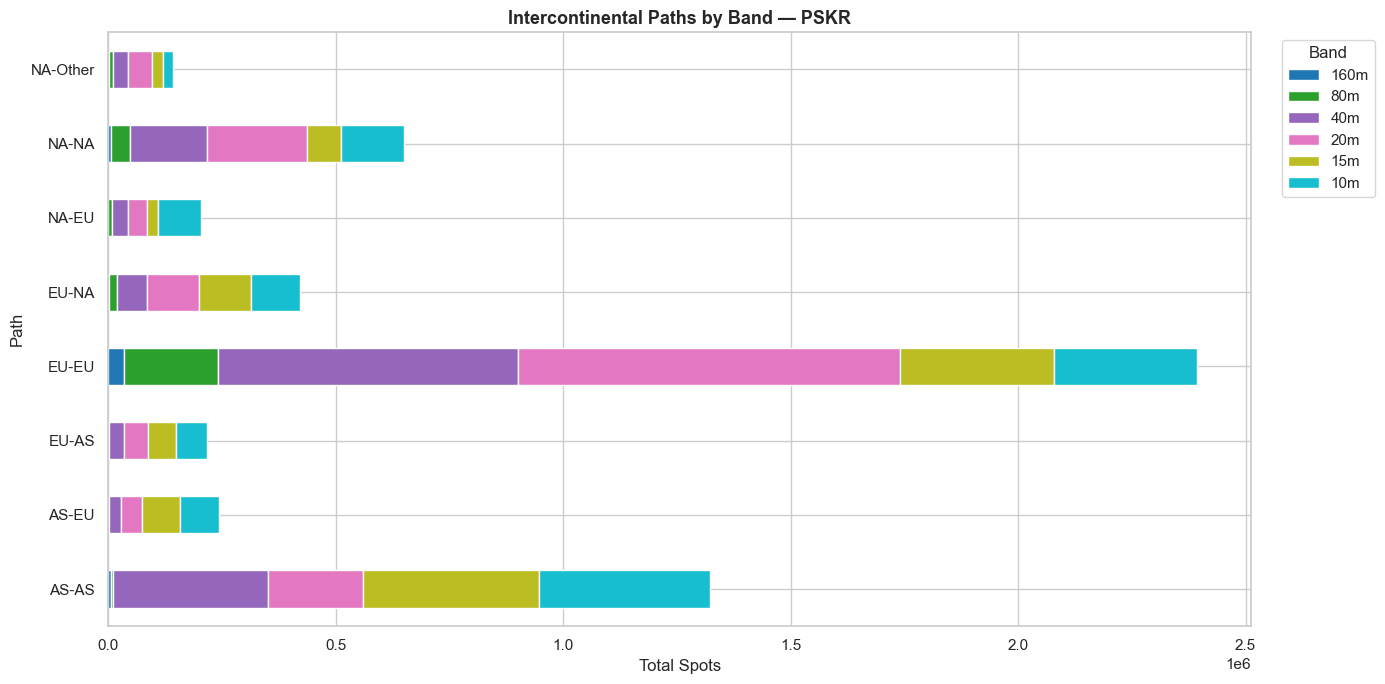

In [12]:
# Intercontinental path breakdown by band
top_paths = path_stats.index[:8].tolist()
inter_df = primary_geo[primary_geo["path"].isin(top_paths) & primary_geo["band"].isin(CONTEST_BANDS)]

fig, ax = plt.subplots(figsize=(14, 7))

pivot = inter_df.groupby(["path", "band"])["spot_count"].sum().unstack(fill_value=0)
pivot.columns = [BAND_NAMES.get(b, str(b)) for b in pivot.columns]
band_order = [BAND_NAMES[b] for b in CONTEST_BANDS if BAND_NAMES[b] in pivot.columns]
pivot = pivot[band_order]

pivot.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
ax.set_xlabel("Total Spots")
ax.set_ylabel("Path")
ax.set_title(f"Intercontinental Paths by Band — {PRIMARY_SOURCE.upper()}", fontsize=13, fontweight="bold")
ax.legend(title="Band", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

---

## Section 5 — Day/Night Analysis

Solar terminator classification of propagation paths:
- **Both-day**: TX and RX both in sunlight
- **Cross-terminator**: one end in daylight, one in darkness (greyline paths)
- **Both-dark**: TX and RX both in darkness

This is where the IONIS model's darkness cross-products (V22-gamma) are validated.
Low bands (160m, 80m) should dominate both-dark paths. High bands (10m, 15m)
should be absent or very weak in both-dark conditions.

In [13]:
# Classify each signature by solar geometry
def classify_signature(row):
    """Classify a signature row by solar geometry using contest start date."""
    dt = datetime(CONTEST_START.year, CONTEST_START.month, CONTEST_START.day,
                  int(row["hour"]), 30, tzinfo=timezone.utc)
    return classify_path(row["tx_grid_4"], row["rx_grid_4"], dt)

# Apply to primary source data
primary_class = primary[primary["band"].isin(CONTEST_BANDS)].copy()
if len(primary_class) > 100_000:
    print(f"Classifying {len(primary_class):,} signatures (may take a moment)...")

primary_class["solar_class"] = primary_class.apply(classify_signature, axis=1)

# Summary
class_counts = primary_class.groupby("solar_class")["spot_count"].sum()
total = class_counts.sum()
print(f"\nSolar Geometry Classification ({PRIMARY_SOURCE.upper()})")
print("=" * 40)
for cls, count in class_counts.items():
    print(f"  {cls:>20}: {count:>10,} spots ({count/total*100:.1f}%)")

Classifying 1,366,465 signatures (may take a moment)...



Solar Geometry Classification (PSKR)
             both-dark:  1,646,473 spots (27.2%)
              both-day:  3,327,668 spots (55.0%)
      cross-terminator:  1,073,929 spots (17.8%)


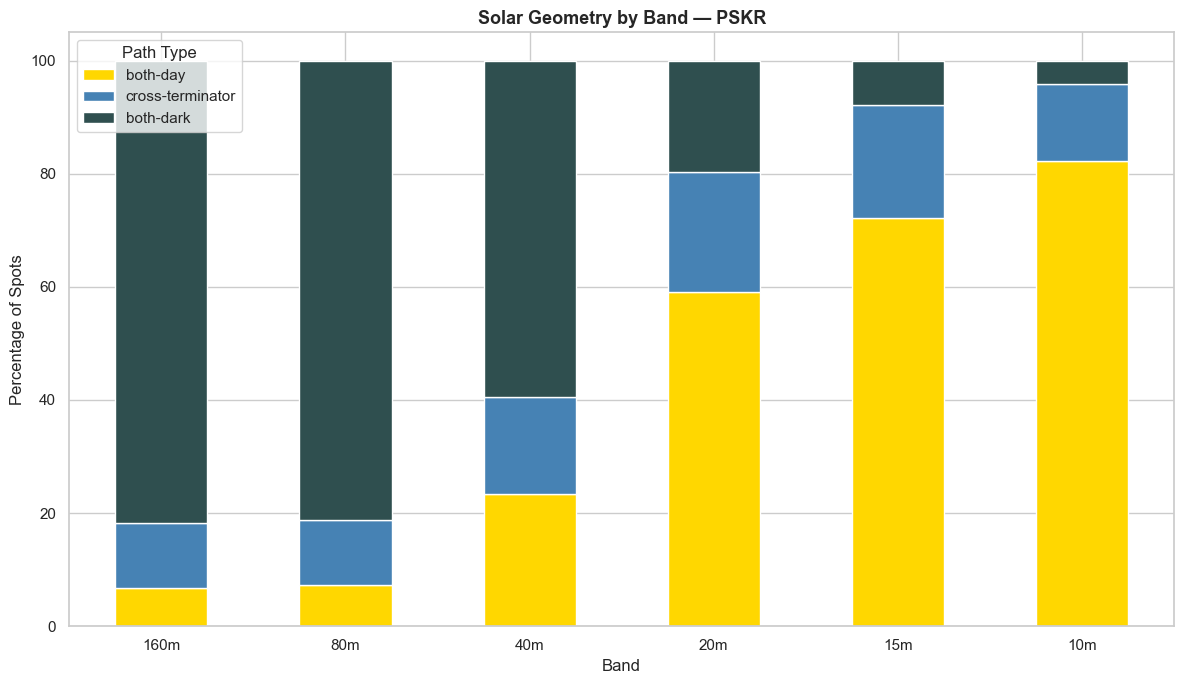

In [14]:
# Day/night breakdown by band
fig, ax = plt.subplots(figsize=(12, 7))

class_by_band = (
    primary_class.groupby(["band", "solar_class"])["spot_count"]
    .sum()
    .unstack(fill_value=0)
)
class_by_band.index = [BAND_NAMES.get(b, str(b)) for b in class_by_band.index]

# Normalize to percentages per band
class_pct = class_by_band.div(class_by_band.sum(axis=1), axis=0) * 100

colors = {"both-day": "#FFD700", "cross-terminator": "#4682B4", "both-dark": "#2F4F4F"}
col_order = [c for c in ["both-day", "cross-terminator", "both-dark"] if c in class_pct.columns]
class_pct[col_order].plot(
    kind="bar", stacked=True, ax=ax,
    color=[colors[c] for c in col_order],
)

ax.set_ylabel("Percentage of Spots")
ax.set_xlabel("Band")
ax.set_title(f"Solar Geometry by Band — {PRIMARY_SOURCE.upper()}", fontsize=13, fontweight="bold")
ax.legend(title="Path Type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

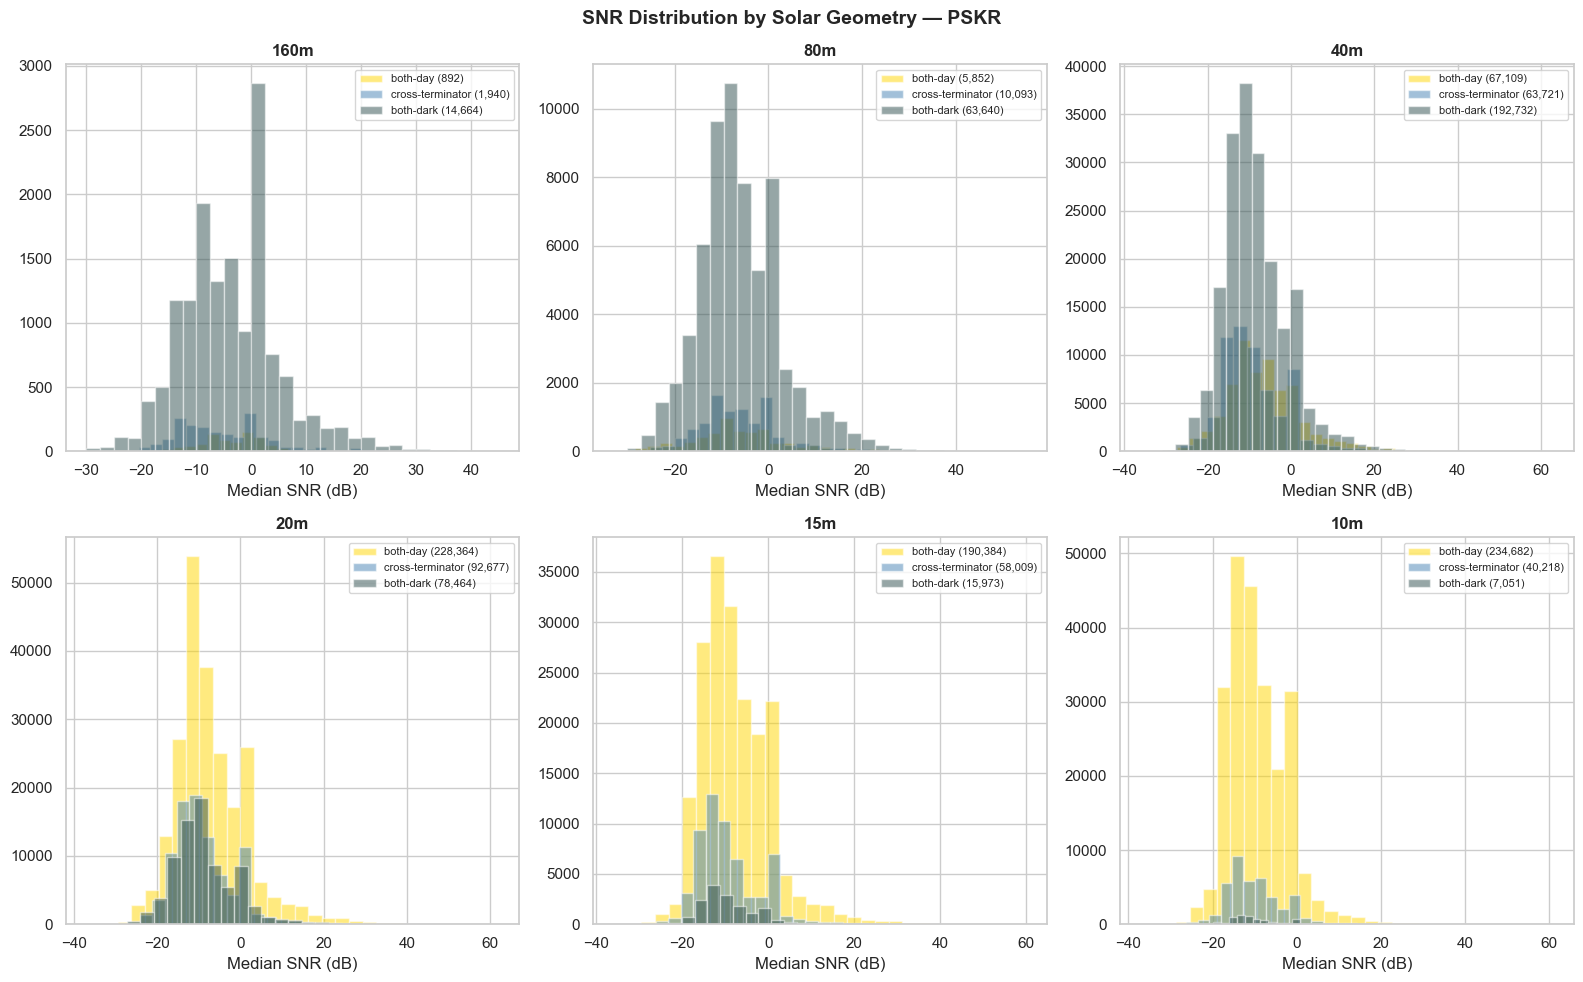

In [15]:
# SNR by solar classification and band
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, band_id in enumerate(CONTEST_BANDS):
    ax = axes[i // 3][i % 3]
    band_df = primary_class[primary_class["band"] == band_id]

    if len(band_df) > 0:
        for cls in ["both-day", "cross-terminator", "both-dark"]:
            cls_df = band_df[band_df["solar_class"] == cls]
            if len(cls_df) > 0:
                ax.hist(cls_df["median_snr"], bins=30, alpha=0.5,
                        label=f"{cls} ({len(cls_df):,})",
                        color=colors.get(cls, "gray"))

    ax.set_title(BAND_NAMES[band_id], fontsize=12, fontweight="bold")
    ax.set_xlabel("Median SNR (dB)")
    ax.legend(fontsize=8)

fig.suptitle(f"SNR Distribution by Solar Geometry — {PRIMARY_SOURCE.upper()}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Section 6 — SNR Distribution

Signal strength analysis across bands, distances, and time-of-day.

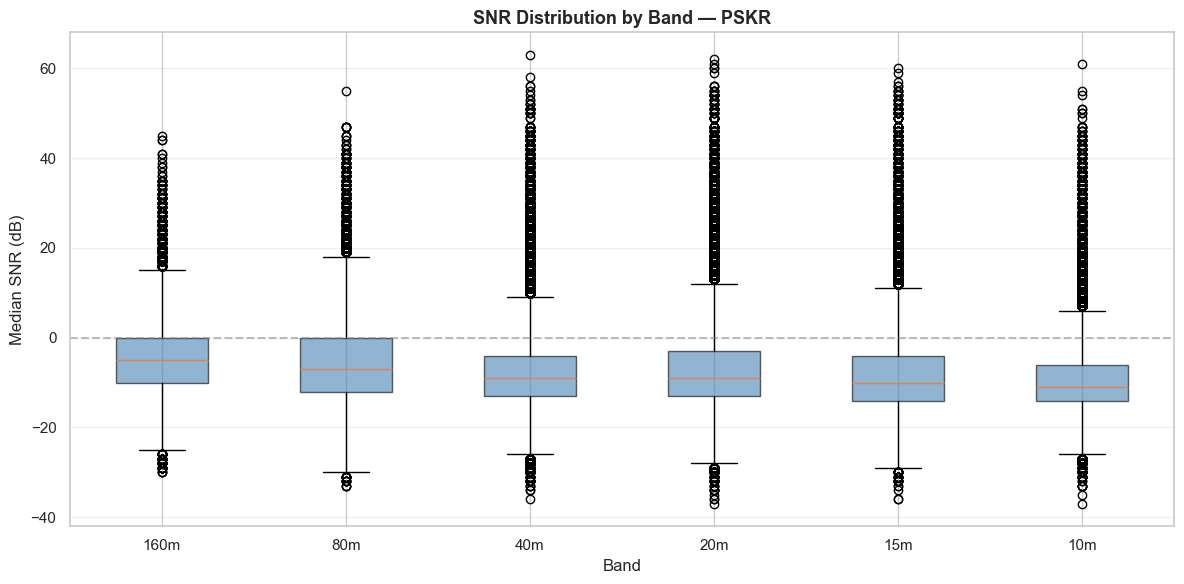

In [16]:
# SNR box plots by band
fig, ax = plt.subplots(figsize=(12, 6))

band_data = []
band_labels = []
for band_id in CONTEST_BANDS:
    data = primary[primary["band"] == band_id]["median_snr"].dropna()
    if len(data) > 0:
        band_data.append(data.values)
        band_labels.append(BAND_NAMES[band_id])

bp = ax.boxplot(band_data, tick_labels=band_labels, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)

ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Band")
ax.set_ylabel("Median SNR (dB)")
ax.set_title(f"SNR Distribution by Band — {PRIMARY_SOURCE.upper()}", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

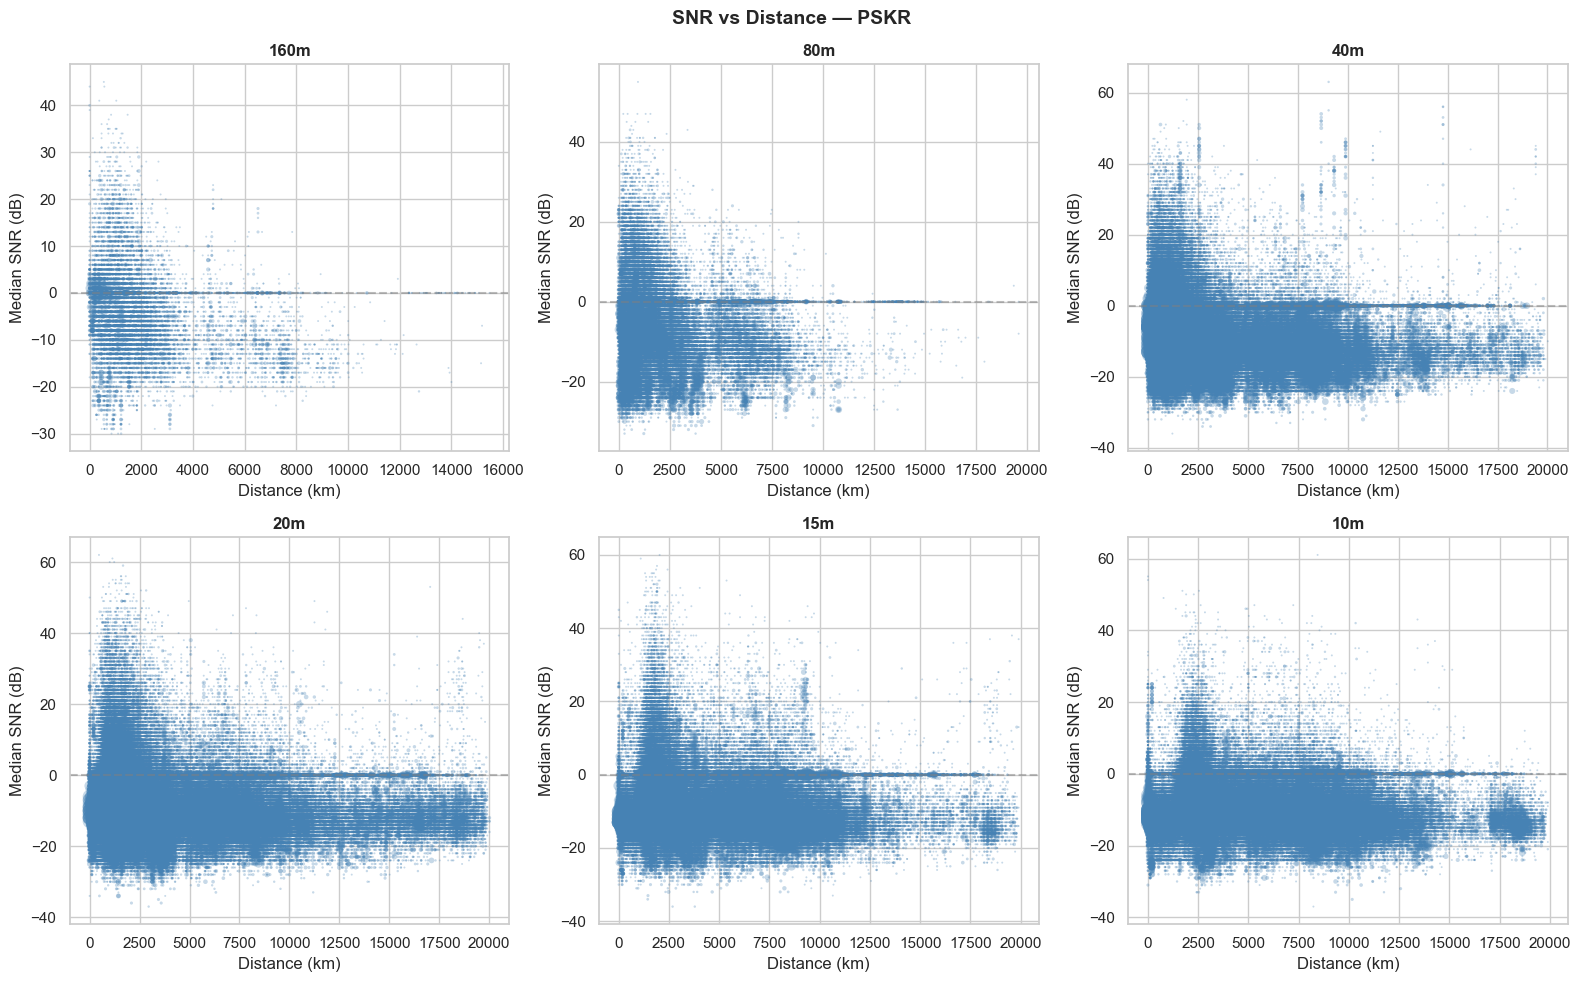

In [17]:
# SNR vs Distance scatter (per band)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, band_id in enumerate(CONTEST_BANDS):
    ax = axes[i // 3][i % 3]
    band_df = primary[primary["band"] == band_id]

    if len(band_df) > 0:
        sizes = np.clip(band_df["spot_count"].values, 1, 100)
        scatter = ax.scatter(
            band_df["avg_distance"], band_df["median_snr"],
            s=sizes, alpha=0.3, c="steelblue", edgecolors="none",
        )
        ax.axhline(0, color="gray", linestyle="--", alpha=0.5)

    ax.set_title(BAND_NAMES[band_id], fontsize=12, fontweight="bold")
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Median SNR (dB)")

fig.suptitle(f"SNR vs Distance — {PRIMARY_SOURCE.upper()}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

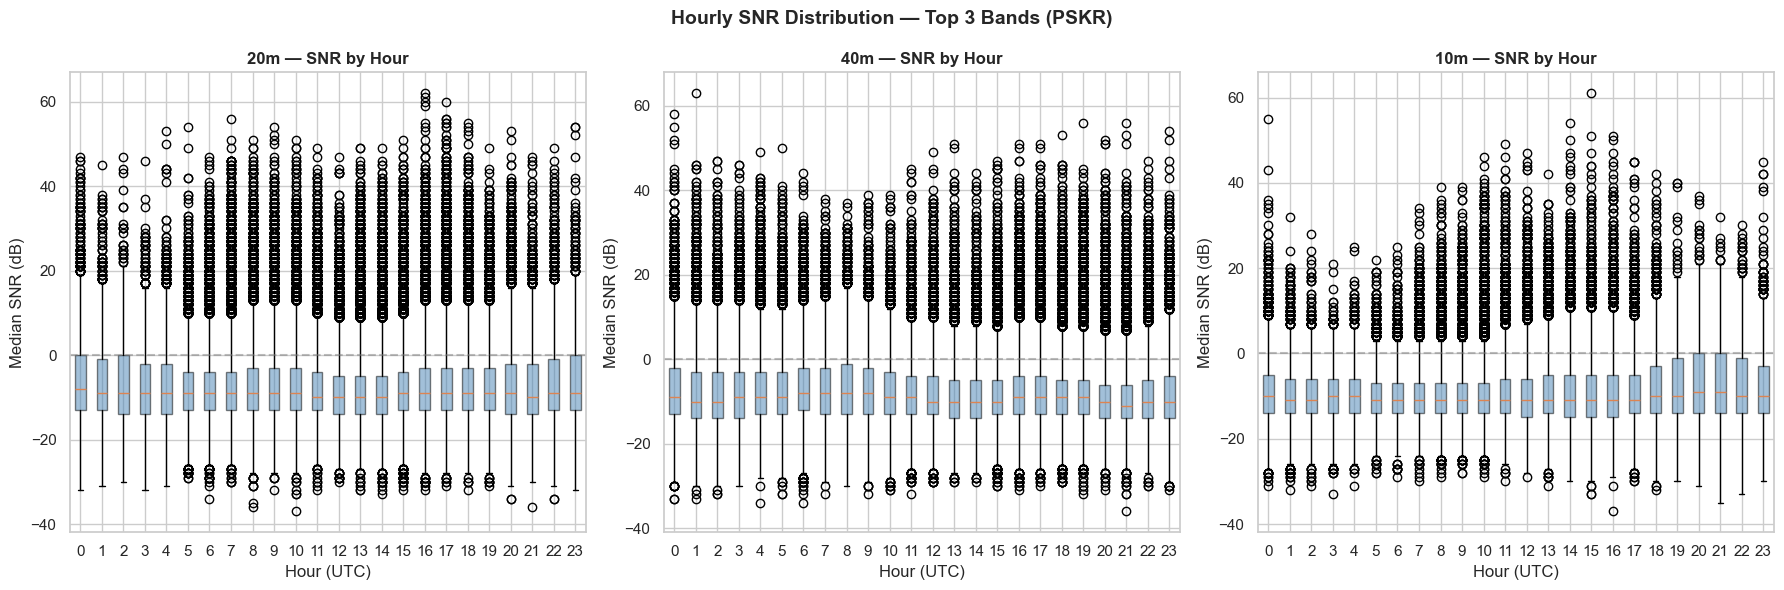

In [18]:
# SNR by hour (box plots) — top 3 bands by activity
top_bands = primary[primary["band"].isin(CONTEST_BANDS)].groupby("band")["spot_count"].sum().nlargest(3).index

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, band_id in enumerate(top_bands):
    ax = axes[i]
    band_df = primary[primary["band"] == band_id]

    hour_groups = [band_df[band_df["hour"] == h]["median_snr"].values
                   for h in range(24)]
    hour_groups = [g if len(g) > 0 else [np.nan] for g in hour_groups]

    bp = ax.boxplot(hour_groups, tick_labels=range(24), patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("steelblue")
        patch.set_alpha(0.5)

    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("Median SNR (dB)")
    ax.set_title(f"{BAND_NAMES[band_id]} — SNR by Hour", fontsize=12, fontweight="bold")

fig.suptitle(f"Hourly SNR Distribution — Top 3 Bands ({PRIMARY_SOURCE.upper()})", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Section 7 — IONIS V22-gamma Comparison

Generate IONIS model predictions for observed PSKR paths and compare with
measured SNR. This validates the model against independent digital mode data
during a geomagnetic storm — a key test of the Kp sidecar's storm cost.

*This section requires the V22-gamma checkpoint and `ionis-training` package.
Skip if not available.*

In [19]:
# Placeholder — model comparison requires V22-gamma checkpoint
# TODO: Load checkpoint, generate predictions for observed paths,
#       scatter plot predicted vs observed SNR, residual analysis

print("Section 7 — IONIS model comparison")
print("Requires: ionis-training + V22-gamma checkpoint")
print("Status: Pending — will be filled in when model inference is integrated")

Section 7 — IONIS model comparison
Requires: ionis-training + V22-gamma checkpoint
Status: Pending — will be filled in when model inference is integrated


---

## Section 8 — Historical Context

Compare this contest weekend with historical contest propagation.
The IONIS `contest.signatures` dataset contains 5.7M signatures from
CQ contests (2005-2025). Band/hour patterns during March contests
provide a useful propagation baseline for the spring equinox period.

In [20]:
# Load historical contest signatures for comparison
try:
    from ionis_jupyter import load_dataset
    contest_hist = load_dataset("contest")
    has_historical = True
    print(f"Loaded {len(contest_hist):,} historical contest signatures")
except (FileNotFoundError, Exception) as e:
    has_historical = False
    print(f"Historical contest data not available: {e}")
    print("Install with: ionis-download --datasets contest")

[Using sample data for 'contest' - contest_signatures_sample.sqlite]
Loaded 2,000 historical contest signatures


Historical March contest signatures: 167


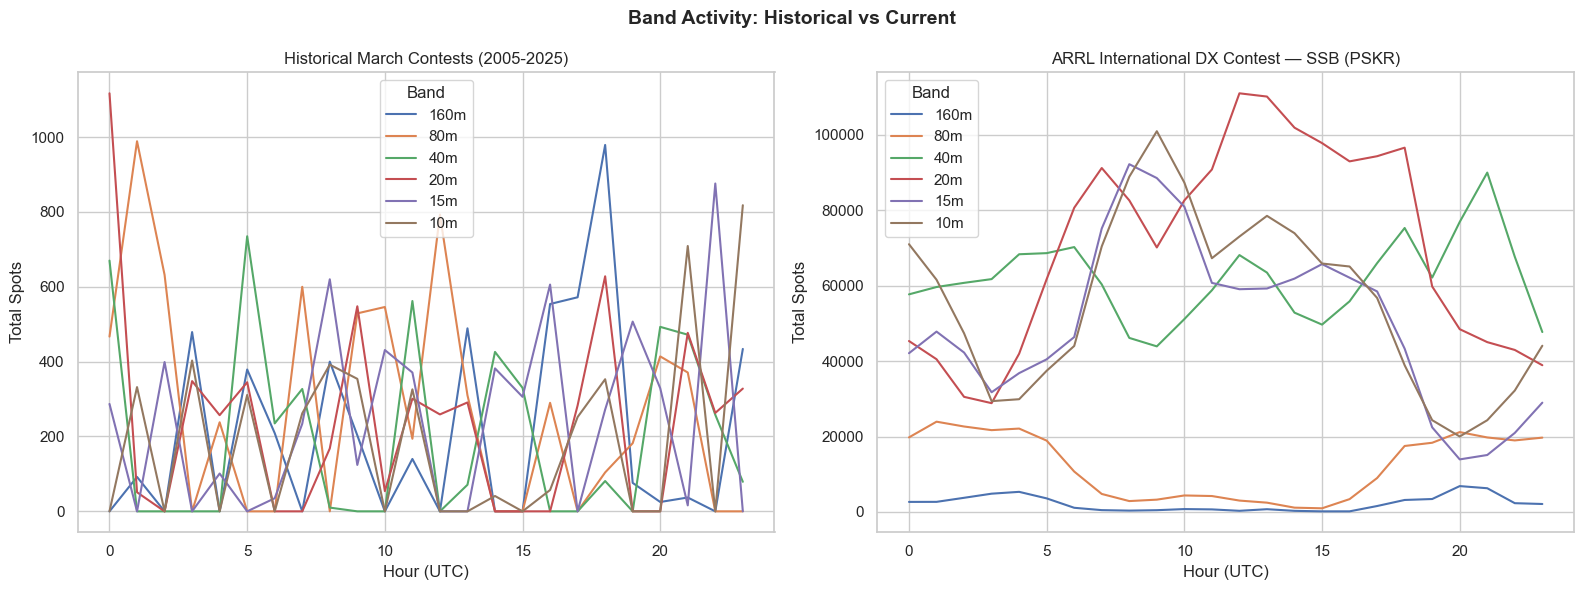

In [21]:
if has_historical:
    # Filter historical data to same month as this contest
    contest_month = CONTEST_START.month
    hist_month = contest_hist[contest_hist["month"] == contest_month]
    month_name = CONTEST_START.strftime("%B")
    print(f"Historical {month_name} contest signatures: {len(hist_month):,}")

    # Compare band activity: historical vs this contest
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Historical
    ax = axes[0]
    hist_bands = hist_month[hist_month["band"].isin(CONTEST_BANDS)]
    hist_pivot = hist_bands.groupby(["hour", "band"])["spot_count"].sum().unstack(fill_value=0)
    hist_pivot.columns = [BAND_NAMES.get(b, str(b)) for b in hist_pivot.columns]
    band_order = [BAND_NAMES[b] for b in CONTEST_BANDS if BAND_NAMES[b] in hist_pivot.columns]
    if band_order:
        hist_pivot[band_order].plot(ax=ax)
    ax.set_title(f"Historical {month_name} Contests (2005-2025)", fontsize=12)
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("Total Spots")
    ax.legend(title="Band")

    # This contest (primary source)
    ax = axes[1]
    primary_bands = primary[primary["band"].isin(CONTEST_BANDS)]
    primary_pivot = primary_bands.groupby(["hour", "band"])["spot_count"].sum().unstack(fill_value=0)
    primary_pivot.columns = [BAND_NAMES.get(b, str(b)) for b in primary_pivot.columns]
    band_order = [BAND_NAMES[b] for b in CONTEST_BANDS if BAND_NAMES[b] in primary_pivot.columns]
    if band_order:
        primary_pivot[band_order].plot(ax=ax)
    ax.set_title(f"{CONTEST_NAME} ({PRIMARY_SOURCE.upper()})", fontsize=12)
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("Total Spots")
    ax.legend(title="Band")

    fig.suptitle("Band Activity: Historical vs Current", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping historical comparison — contest dataset not available.")

[Using sample data for 'solar' - solar_indices_sample.sqlite]


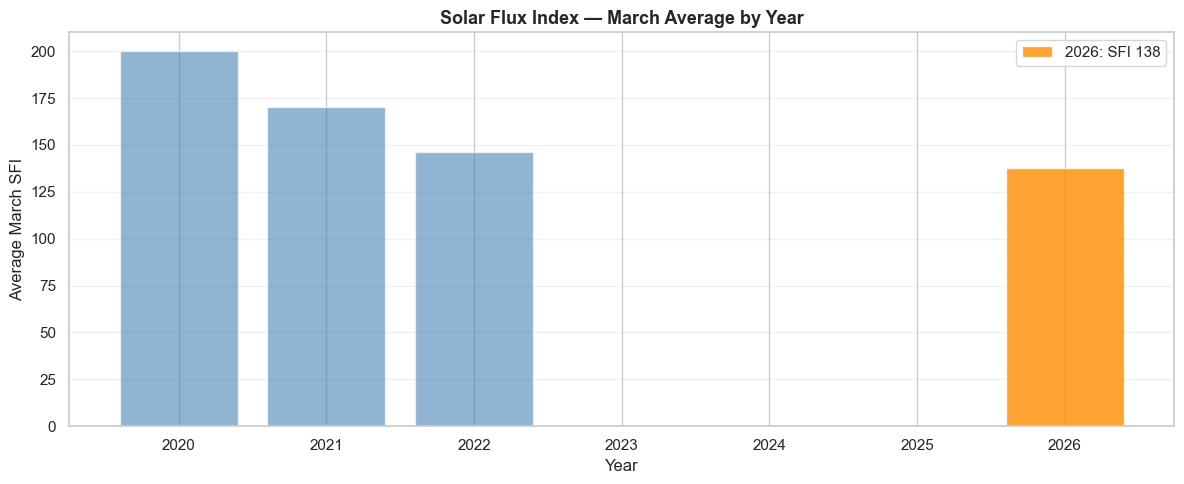

In [22]:
if has_historical:
    # Solar cycle context
    # SFI during this contest vs historical averages for the same month
    try:
        solar_hist = load_dataset("solar")
        solar_hist["date"] = pd.to_datetime(solar_hist["date"])
        month_name = CONTEST_START.strftime("%B")
        solar_month = solar_hist[solar_hist["date"].dt.month == contest_month]

        # Average SFI by year for this month
        solar_month_yearly = solar_month.groupby(solar_month["date"].dt.year)["sfi"].mean()

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.bar(solar_month_yearly.index, solar_month_yearly.values, color="steelblue", alpha=0.6)

        # Highlight this year
        current_sfi = solar["sfi"].mean() if "sfi" in solar.columns else None
        if current_sfi and 2026 in solar_month_yearly.index:
            ax.bar(2026, solar_month_yearly[2026], color="darkorange", alpha=0.8, label=f"2026: SFI {current_sfi:.0f}")
        elif current_sfi:
            ax.bar(2026, current_sfi, color="darkorange", alpha=0.8, label=f"2026: SFI {current_sfi:.0f}")

        ax.set_xlabel("Year")
        ax.set_ylabel(f"Average {month_name} SFI")
        ax.set_title(f"Solar Flux Index — {month_name} Average by Year", fontsize=13, fontweight="bold")
        ax.legend()
        ax.grid(True, alpha=0.3, axis="y")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Solar historical comparison skipped: {e}")

---

## Section 9 — Key Findings

Summary of propagation highlights from the contest weekend.

In [23]:
# Auto-generate summary statistics for the findings section
print("=" * 60)
print(f"KEY FINDINGS — {CONTEST_NAME.upper()}")
print("=" * 60)

# Solar conditions
if "sfi" in solar.columns:
    sfi_mean = solar["sfi"].mean()
    print(f"\n1. Solar conditions: SFI {sfi_mean:.0f} (moderate)")

if "kp" in solar.columns:
    kp_max = solar["kp"].max()
    kp_mean = solar["kp"].mean()
    if kp_max >= 4:
        print(f"   Geomagnetic storm: Kp reached {kp_max:.1f} (mean {kp_mean:.1f})")
    else:
        print(f"   Geomagnetic: quiet to unsettled (Kp max {kp_max:.1f}, mean {kp_mean:.1f})")

# Band activity
print(f"\n2. {PRIMARY_SOURCE.upper()} captured {primary['spot_count'].sum():,.0f} total spots across {len(primary):,} signatures")
secondary_src = "PSKR" if PRIMARY_SOURCE == "rbn" else "RBN"
print(f"   {secondary_src} captured {secondary['spot_count'].sum():,.0f} total spots across {len(secondary):,} signatures")

# Most active band
band_totals = primary[primary["band"].isin(CONTEST_BANDS)].groupby("band")["spot_count"].sum().sort_values(ascending=False)
if len(band_totals) > 0:
    top_band = band_totals.index[0]
    print(f"\n3. Most active band: {BAND_NAMES[top_band]} ({band_totals.iloc[0]:,.0f} spots)")
    if len(band_totals) > 1:
        print(f"   Runner-up: {BAND_NAMES[band_totals.index[1]]} ({band_totals.iloc[1]:,.0f} spots)")

# Geographic reach
max_dist = primary["avg_distance"].max()
mean_dist = np.average(primary["avg_distance"], weights=primary["spot_count"])
print(f"\n4. Geographic reach: max {max_dist:,.0f} km, weighted mean {mean_dist:,.0f} km")
print(f"   Unique TX grids: {primary['tx_grid_4'].nunique():,}, RX grids: {primary['rx_grid_4'].nunique():,}")

# Day/night
if "solar_class" in primary_class.columns:
    dark_spots = primary_class[primary_class["solar_class"] == "both-dark"]["spot_count"].sum()
    total_spots = primary_class["spot_count"].sum()
    print(f"\n5. Both-dark paths: {dark_spots:,.0f} spots ({dark_spots/total_spots*100:.1f}% of total)")

print("\n" + "=" * 60)
print("Analysis produced by IONIS-AI + QSO-Graph")
print(f"Dataset: {DATASET_NAME}")
print(f"Generated: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')}")

KEY FINDINGS — ARRL INTERNATIONAL DX CONTEST — SSB

1. Solar conditions: SFI 138 (moderate)
   Geomagnetic storm: Kp reached 4.7 (mean 2.8)

2. PSKR captured 7,915,098 total spots across 1,830,861 signatures
   RBN captured 506,815 total spots across 129,848 signatures



3. Most active band: 20m (1,687,063 spots)
   Runner-up: 40m (1,483,169 spots)

4. Geographic reach: max 20,015 km, weighted mean 3,754 km


   Unique TX grids: 1,904, RX grids: 1,347



5. Both-dark paths: 1,646,473 spots (27.2% of total)

Analysis produced by IONIS-AI + QSO-Graph
Dataset: arrl-dx-ssb-2026.sqlite
Generated: 2026-03-09 20:49 UTC


---

*Analysis by [IONIS-AI](https://github.com/IONIS-AI) and [QSO-Graph](https://github.com/qso-graph).  
Data: 14.3B propagation observations, 71 MCP tools.  
License: MIT*